In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import time

## Load data, preprocessing

In [2]:
import os
import kagglehub
from tensorflow.keras.utils import load_img, img_to_array
from sklearn.model_selection import train_test_split

# 1) Download dataset
path = kagglehub.dataset_download("meowmeowmeowmeowmeow/gtsrb-german-traffic-sign")
print("Dataset path:", path)
print("Files:", os.listdir(path))

# 2) Read CSV files
train_df = pd.read_csv(os.path.join(path, "Train.csv"))
test_df  = pd.read_csv(os.path.join(path, "Test.csv"))

print(train_df.head())
print(test_df.head())

# 3) Load images into arrays
IMG_SIZE = (32, 32)

def load_images_from_csv(df, base_path, img_size=(32, 32)):
    images = []
    labels = []

    for _, row in df.iterrows():
        img_path = os.path.join(base_path, row["Path"])
        img = load_img(img_path, target_size=img_size)
        img = img_to_array(img)
        images.append(img)
        labels.append(row["ClassId"])

    x = np.array(images, dtype="float32")
    y = np.array(labels, dtype="int32")
    return x, y

x_train_full, y_train_full = load_images_from_csv(train_df, path, IMG_SIZE)
x_test, y_test = load_images_from_csv(test_df, path, IMG_SIZE)

# 4) Split train/val
x_train, x_val, y_train, y_val = train_test_split(
    x_train_full,
    y_train_full,
    test_size=0.2,
    random_state=42,
    stratify=y_train_full
)

# 5) Normalize
x_train = x_train / 255.0
x_val   = x_val / 255.0
x_test  = x_test / 255.0

# 6) Check data
print(f"Train: {x_train.shape} | Val: {x_val.shape} | Test: {x_test.shape}")
print(f"Pixel range: [{x_train.min()}, {x_train.max()}]")
print(f"Image shape: {x_train[0].shape}")
print(f"Number of classes: {len(np.unique(y_train_full))}")

c:\Users\zeyad\anaconda3\envs\ml\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Resuming download from 49283072 bytes (592285720 bytes left)...
Resuming download to C:\Users\zeyad\.cache\kagglehub\datasets\meowmeowmeowmeowmeow\gtsrb-german-traffic-sign\1.archive (49283072/641568792) bytes left.


100%|██████████| 612M/612M [04:15<00:00, 2.32MB/s] 

Extracting files...


Dataset path: C:\Users\zeyad\.cache\kagglehub\datasets\meowmeowmeowmeowmeow\gtsrb-german-traffic-sign\versions\1
Files: ['Meta', 'Meta.csv', 'Test', 'Test.csv', 'Train', 'Train.csv']
   Width  Height  Roi.X1  Roi.Y1  Roi.X2  Roi.Y2  ClassId  \
0     27      26       5       5      22      20       20   
1     28      27       5       6      23      22       20   
2     29      26       6       5      24      21       20   
3     28      27       5       6      23      22       20   
4     28      26       5       5      23      21       20   

                             Path  
0  Train/20/00020_00000_00000.png  
1  Train/20/00020_00000_00001.png  
2  Train/20/00020_00000_00002.png  
3  Train/20/00020_00000_00003.png  
4  Train/20/00020_00000_00004.png  
   Width  Height  Roi.X1  Roi.Y1  Roi.X2  Roi.Y2  ClassId            Path
0     53      54       6       5      48      49       16  Test/00000.png
1     42      45       5       5      36      40        1  Test/00001.png
2     48    

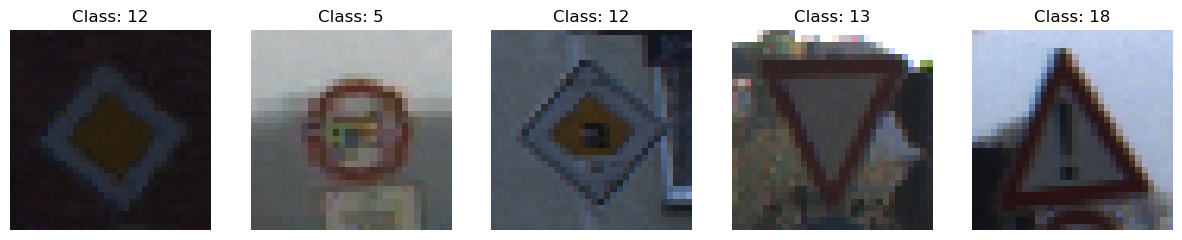

In [3]:
plt.figure(figsize=(15, 5))

for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(x_train[i])
    plt.title(f"Class: {y_train[i]}")
    plt.axis('off') 
plt.show()

### Augmntation

In [4]:
from tensorflow.keras import layers, Sequential

data_augmentation = Sequential([
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.10),
    layers.RandomTranslation(height_factor=0.08, width_factor=0.08),
    layers.RandomContrast(0.10)
], name="data_augmentation")

## CNN 

In [5]:
num_classes = len(set(y_train))

def build_baseline_cnn():
    model = models.Sequential([
        layers.Input(shape=x_train.shape[1:]),

        # 1) augmentation
        data_augmentation,


        # Block 1
        layers.Conv2D(32, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.MaxPooling2D((2, 2)),

        # Block 2
        layers.Conv2D(64, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.MaxPooling2D((2, 2)),

        # Block 3
        layers.Conv2D(128, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.MaxPooling2D((2, 2)),

        layers.Flatten(),
        layers.Dense(128),
        layers.ReLU(),
        layers.Dropout(0.5),

        layers.Dense(num_classes, activation='softmax')
    ])

    return model

In [6]:
num_classes = len(np.unique(y_train))

y_train_cat = to_categorical(y_train, num_classes=num_classes)
y_val_cat   = to_categorical(y_val, num_classes=num_classes)
y_test_cat  = to_categorical(y_test, num_classes=num_classes)


In [7]:
model = build_baseline_cnn()
model.summary() 
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(x_train, y_train_cat, validation_data=(x_val, y_val_cat), epochs=20, batch_size=32)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 43)             │         5,547 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 361,963 (1.38 MB)

 Trainable params: 361,515 (1.38 MB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/20
981/981 ━━━━━━━━━━━━━━━━━━━━ 37s 33ms/step - accuracy: 0.1708 - loss: 2.9586 - val_accuracy: 0.3892 - val_loss: 2.0289
Epoch 2/20
981/981 ━━━━━━━━━━━━━━━━━━━━ 32s 32ms/step - accuracy: 0.2659 - loss: 2.3262 - val_accuracy: 0.4948 - val_loss: 1.5624
Epoch 3/20
981/981 ━━━━━━━━━━━━━━━━━━━━ 31s 32ms/step - accuracy: 0.2955 - loss: 2.1742 - val_accuracy: 0.5024 - val_loss: 1.4553
Epoch 4/20
981/981 ━━━━━━━━━━━━━━━━━━━━ 32s 32ms/step - accuracy: 0.3114 - loss: 2.1125 - val_accuracy: 0.5223 - val_loss: 1.4236
Epoch 5/20
981/981 ━━━━━━━━━━━━━━━━━━━━ 32s 32ms/step - accuracy: 0.3361 - loss: 2.0358 - val_accuracy: 0.5926 - val_loss: 1.2776
Epoch 6/20
981/981 ━━━━━━━━━━━━━━━━━━━━ 32s 32ms/step - accuracy: 0.3485 - loss: 1.9762 - val_accuracy: 0.6273 - val_loss: 1.1586
Epoch 7/20
981/981 ━━━━━━━━━━━━━━━━━━━━ 31s 32ms/step - accuracy: 0.3763 - loss: 1.8683 - val_accuracy: 0.6247 - val_loss: 1.1830
Epoch 8/20
981/981 ━━━━━━━━━━━━━━━━━━━━ 31s 31ms/step - accuracy: 0.3883 - loss: 1.8157 - 

In [8]:
test_loss, test_acc = model.evaluate(x_test, y_test_cat, verbose=0)
print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)

Test Loss: 0.2750342786312103
Test Accuracy: 0.9171813130378723


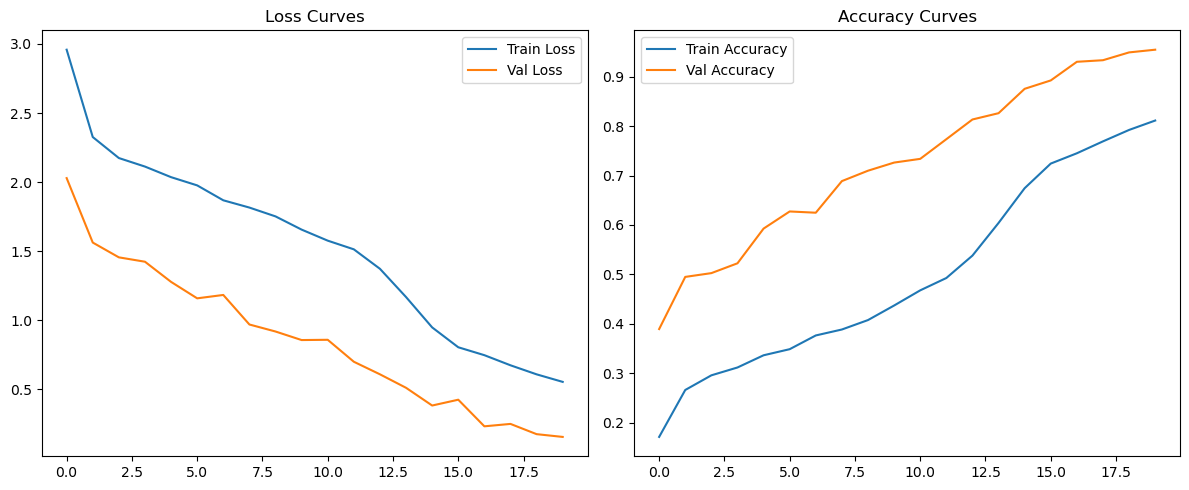

In [9]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title('Loss Curves')

plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title('Accuracy Curves')

plt.tight_layout()
plt.show()

## Optimizer comparision

In [10]:
from tensorflow.keras.optimizers import SGD, Adam, RMSprop


optimizers_dict = {
    "SGD": SGD(learning_rate=0.01),
    "SGD_momentum": SGD(learning_rate=0.01, momentum=0.9),
    "Adam": Adam(learning_rate=0.001),
    "RMSprop": RMSprop(learning_rate=0.001)
}

In [11]:
results = {}
histories = {}

In [12]:
for opt_name, opt in optimizers_dict.items():
    print(f"\nTraining with {opt_name}...\n")

    model = build_baseline_cnn()
    model.summary()

    model.compile(
        optimizer=opt,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    history = model.fit(
        x_train, y_train_cat,
        validation_data=(x_val, y_val_cat),
        epochs=20,
        batch_size=32,
        verbose=1
    )

    test_loss, test_acc = model.evaluate(x_test, y_test_cat, verbose=0)

    best_val_acc = max(history.history['val_accuracy'])
    final_train_acc = history.history['accuracy'][-1]
    final_val_loss = history.history['val_loss'][-1]

    results[opt_name] = {
        "best_val_acc": best_val_acc,
        "test_acc": test_acc,
        "final_train_acc": final_train_acc,
        "final_val_loss": final_val_loss
    }

    histories[opt_name] = history


Training with SGD...



Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_4 (ReLU)                  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_5 (ReLU)                  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_6 (ReLU)                  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_7 (ReLU)                  │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 43)             │         5,547 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 361,963 (1.38 MB)

 Trainable params: 361,515 (1.38 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_16 (ReLU)                 │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_17 (ReLU)                 │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_18 (ReLU)                 │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_19 (ReLU)                 │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 43)             │         5,547 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 361,963 (1.38 MB)

 Trainable params: 361,515 (1.38 MB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/20
981/981 ━━━━━━━━━━━━━━━━━━━━ 21s 20ms/step - accuracy: 0.2084 - loss: 2.8600 - val_accuracy: 0.4634 - val_loss: 1.7566
Epoch 2/20
981/981 ━━━━━━━━━━━━━━━━━━━━ 20s 20ms/step - accuracy: 0.3758 - loss: 1.9603 - val_accuracy: 0.6062 - val_loss: 1.1876
Epoch 3/20
981/981 ━━━━━━━━━━━━━━━━━━━━ 20s 20ms/step - accuracy: 0.4610 - loss: 1.6075 - val_accuracy: 0.7297 - val_loss: 0.8060
Epoch 4/20
981/981 ━━━━━━━━━━━━━━━━━━━━ 20s 20ms/step - accuracy: 0.5477 - loss: 1.3545 - val_accuracy: 0.8059 - val_loss: 0.6500
Epoch 5/20
981/981 ━━━━━━━━━━━━━━━━━━━━ 20s 20ms/step - accuracy: 0.6375 - loss: 1.0849 - val_accuracy: 0.8761 - val_loss: 0.3826
Epoch 6/20
981/981 ━━━━━━━━━━━━━━━━━━━━ 20s 20ms/step - accuracy: 0.6959 - loss: 0.9241 - val_accuracy: 0.8605 - val_loss: 0.4209
Epoch 7/20
981/981 ━━━━━━━━━━━━━━━━━━━━ 20s 21ms/step - accuracy: 0.7425 - loss: 0.7807 - val_accuracy: 0.8761 - val_loss: 0.4021
Epoch 8/20
981/981 ━━━━━━━━━━━━━━━━━━━━ 20s 21ms/step - accuracy: 0.7901 - loss: 0.6406 - 

In [13]:
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values(by="best_val_acc", ascending=False)
print(results_df)

              best_val_acc  test_acc  final_train_acc  final_val_loss
RMSprop           0.987886  0.939509         0.947684        0.091181
SGD               0.985590  0.952257         0.930405        0.049620
SGD_momentum      0.980490  0.947427         0.941913        0.064211
Adam              0.966208  0.910847         0.829789        0.159097


### implementing autoencoders to reduce images noise

In [25]:
autoencoder = models.Sequential([
    layers.Conv2D(32, (3, 3), activation= "relu", padding= "same", input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),
    # currunt shape 16 * 16
    layers.Conv2D(64, (3, 3), activation= "relu", padding= "same"),
    layers.MaxPooling2D((2, 2)),
    # current shape 8 * 8
    layers.Conv2D(128, (3, 3), activation= "relu", padding= "same"),
    layers.MaxPooling2D((2, 2)),
    # current shape 4 * 4
    layers.Conv2D(128, (3, 3), activation="relu", padding= "same"),
    layers.Conv2DTranspose(32, (3, 3), strides= (2, 2), padding= "same"),
    # current shape 8 * 8
    layers.Conv2D(128, (3, 3), activation= "relu", padding= "same"),
    layers.Conv2DTranspose(32, (3, 3), strides= (2, 2), padding = "same"),
    # current shape 16 * 16
    layers.Conv2D(64, (3, 3), activation= "relu", padding= "same"),
    layers.Conv2DTranspose(32, (3, 3), strides= (2, 2), padding= "same"),
    # current shape 32 * 32
    layers.Conv2D(3, (3, 3), activation= "sigmoid", padding= "same")
])
autoencoder.compile(optimizer="adam", loss="mse", metrics=["accuracy"])
autoencoder.fit(x_train, x_train, validation_data=(x_val, x_val), epochs=50, batch_size=32, callbacks=[callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)])

c:\Users\zeyad\anaconda3\envs\ml\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
981/981 ━━━━━━━━━━━━━━━━━━━━ 20s 18ms/step - accuracy: 0.5836 - loss: 0.0157 - val_accuracy: 0.7193 - val_loss: 0.0094
Epoch 2/50
981/981 ━━━━━━━━━━━━━━━━━━━━ 18s 18ms/step - accuracy: 0.7243 - loss: 0.0076 - val_accuracy: 0.7412 - val_loss: 0.0063
Epoch 3/50
981/981 ━━━━━━━━━━━━━━━━━━━━ 18s 18ms/step - accuracy: 0.7421 - loss: 0.0060 - val_accuracy: 0.7354 - val_loss: 0.0056
Epoch 4/50
981/981 ━━━━━━━━━━━━━━━━━━━━ 18s 18ms/step - accuracy: 0.7522 - loss: 0.0053 - val_accuracy: 0.7502 - val_loss: 0.0052
Epoch 5/50
981/981 ━━━━━━━━━━━━━━━━━━━━ 18s 18ms/step - accuracy: 0.7566 - loss: 0.0048 - val_accuracy: 0.7397 - val_loss: 0.0047
Epoch 6/50
981/981 ━━━━━━━━━━━━━━━━━━━━ 18s 18ms/step - accuracy: 0.7590 - loss: 0.0045 - val_accuracy: 0.7597 - val_loss: 0.0044
Epoch 7/50
981/981 ━━━━━━━━━━━━━━━━━━━━ 18s 19ms/step - accuracy: 0.7624 - loss: 0.0043 - val_accuracy: 0.7010 - val_loss: 0.0042
Epoch 8/50
981/981 ━━━━━━━━━━━━━━━━━━━━ 19s 19ms/step - accuracy: 0.7654 - loss: 0.0041 - 

In [26]:
autoencoder.summary()

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_65 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_36 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_66 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_37 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_67 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_38 (MaxPooling2D) │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_68 (Conv2D)              │ (None, 4, 4, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_21             │ (None, 8, 8, 32)       │        36,896 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_69 (Conv2D)              │ (None, 8, 8, 128)      │        36,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_22             │ (None, 16, 16, 32)     │        36,896 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_70 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_23             │ (None, 32, 32, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_71 (Conv2D)              │ (None, 32, 32, 3)      │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,168,331 (4.46 MB)

 Trainable params: 389,443 (1.49 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 778,888 (2.97 MB)

395/395 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step


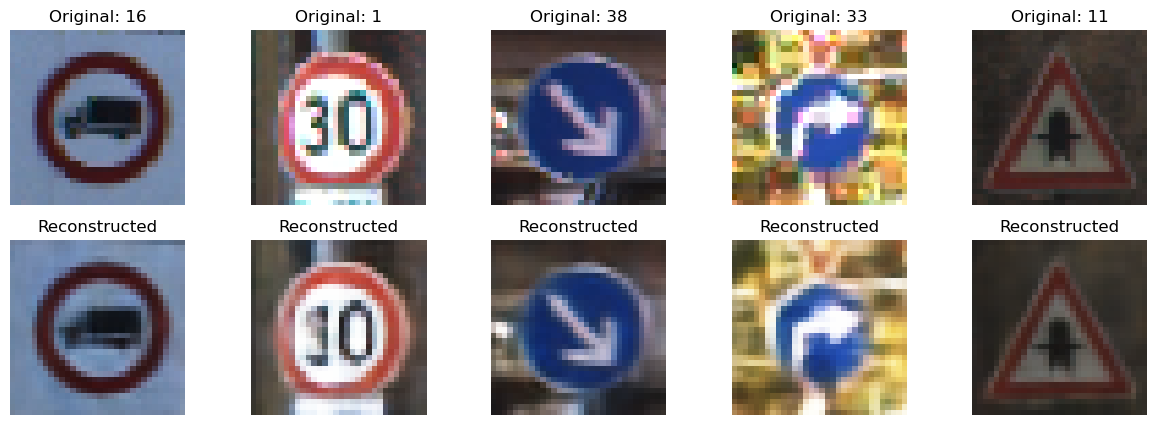

In [ ]:
reconstructed = autoencoder.predict(x_test)
plt.figure(figsize=(15, 5))
for i in range(5):
    plt.subplot(2, 5, i+1)
    plt.imshow(x_test[i])
    plt.title(f"Original: {y_test[i]}")
    plt.axis('off')

    plt.subplot(2, 5, 5+i+1)
    plt.imshow(reconstructed[i])
    plt.title("Reconstructed")
    plt.axis('off')

In [28]:
x_train_encoded = autoencoder.predict(x_train)
x_val_encoded = autoencoder.predict(x_val)
x_test_encoded = autoencoder.predict(x_test)

981/981 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step
246/246 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step
395/395 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step


### implementing transfer learning on the encoded images using vgg16

In [33]:
from tensorflow.keras.applications import VGG16
vgg_base = VGG16(weights="imagenet", include_top=False, input_shape=(32, 32, 3))
vgg_base.trainable = False
for layer in vgg_base.layers[:-4]:
    layer.trainable = True
transfer_model = models.Sequential([
    vgg_base,
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation="softmax")
])
transfer_model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
transfer_model.fit(x_train_encoded, y_train_cat, validation_data=(x_val_encoded, y_val_cat), epochs=20, batch_size=32, callbacks=[callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)])
transfer_model.summary()

Epoch 1/20
981/981 ━━━━━━━━━━━━━━━━━━━━ 147s 147ms/step - accuracy: 0.2437 - loss: 2.6436 - val_accuracy: 0.4869 - val_loss: 1.4121
Epoch 2/20
981/981 ━━━━━━━━━━━━━━━━━━━━ 145s 148ms/step - accuracy: 0.6378 - loss: 1.0591 - val_accuracy: 0.7478 - val_loss: 0.6941
Epoch 3/20
981/981 ━━━━━━━━━━━━━━━━━━━━ 143s 146ms/step - accuracy: 0.8294 - loss: 0.5043 - val_accuracy: 0.8999 - val_loss: 0.3413
Epoch 4/20
981/981 ━━━━━━━━━━━━━━━━━━━━ 144s 147ms/step - accuracy: 0.9075 - loss: 0.3120 - val_accuracy: 0.9393 - val_loss: 0.2091
Epoch 5/20
981/981 ━━━━━━━━━━━━━━━━━━━━ 145s 148ms/step - accuracy: 0.9366 - loss: 0.2242 - val_accuracy: 0.9501 - val_loss: 0.1865
Epoch 6/20
981/981 ━━━━━━━━━━━━━━━━━━━━ 145s 148ms/step - accuracy: 0.9535 - loss: 0.1761 - val_accuracy: 0.9554 - val_loss: 0.1642
Epoch 7/20
981/981 ━━━━━━━━━━━━━━━━━━━━ 145s 148ms/step - accuracy: 0.9600 - loss: 0.1607 - val_accuracy: 0.9528 - val_loss: 0.1590
Epoch 8/20
981/981 ━━━━━━━━━━━━━━━━━━━━ 146s 148ms/step - accuracy: 0.9658 -

Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 1, 1, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_8 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 43)             │         5,547 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,198,851 (115.20 MB)

 Trainable params: 7,706,475 (29.40 MB)

 Non-trainable params: 7,079,424 (27.01 MB)

 Optimizer params: 15,412,952 (58.80 MB)

In [34]:
test_loss, test_acc = transfer_model.evaluate(x_test_encoded, y_test_cat, verbose=0)
print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)

Test Loss: 0.6816263794898987
Test Accuracy: 0.9150435328483582
